In [18]:
from sctoolbox.utils.jupyter import bgcolor, _compare_version

# change the background of input cells
bgcolor("PowderBlue", select=[3, 6, 9, 11])

nb_name = "annotation.ipynb"

_compare_version(nb_name)

# Cell type annotation and marker list assembly
<hr style="border:2px solid black"> </hr>

## 1 - Description

**Requires a clustered or otherwise categorized anndata object. A clustering can be generated with a clustering notebook (e.g. `rna_analysis/notebooks/04_clustering.ipynb`).**

**Move this notebook into the notebook folder (e.g. `rna_analysis/notebooks/`) of the respective analysis before using it!**

This Jupyter Notebook is designed for annotating cell types in clustered AnnData objects. It is divided into two main parts:

- **Marker List Assembly**: This part is used when no existing marker lists are available. It enables users to assemble custom marker lists using the MarkerRepo.

- **Annotation**: This section applies the created or provided marker lists to annotate cell types in AnnData objects.


For more information about MarkerRepo, click [here](https://gitlab.gwdg.de/loosolab/software/annotate_by_marker_and_features).

--------------

## 2- Setup

In [2]:
from sctoolbox import settings
import sctoolbox.utils as utils
import sctoolbox.plotting as pl
import os
import pandas as pd
pd.set_option('display.max_columns', None)  # no limit to the number of columns shown

settings.settings_from_config("config.yaml", key="annoation")

Created directory: ../figures/annotation/
Created directory: ../tables/annotation/
Created directory: ../report/annotation/


In [3]:
try:
    import markerrepo.wrappers as wrap
    import markerrepo.marker_repo as mr
except ModuleNotFoundError:
    raise ModuleNotFoundError("Please install the latest MarkerRepo version.")
    
with pd.option_context("display.max.rows", None, "display.max_colwidth", None):
    display(utils.general.get_version_report(report="versions.yml"))

/mnt/workspace2/hschult/.conda/sctoolbox/lib/python3.12/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


,Name,Version
0,Python,"3.12.12 | packaged by conda-forge | (main, Oct 22 2025, 23:25:55) [GCC 14.3.0]"
1,numpy,2.3.5
2,markerrepo,0.1
3,sctoolbox,NA
4,anndata,0.12.6
5,scanpy,1.11.5
6,pandas,2.3.3


<h1><center>⬐ Fill in input data here ⬎</center></h1>

In [4]:
# Set inpput anndata
clustered_adata = "anndata_marker.h5ad"

___

## 3 - Loading adata

In [5]:
adata = utils.adata.load_h5ad(clustered_adata)

[INFO] The adata object was loaded from: ../adatas/anndata_marker.h5ad


In [6]:
with pd.option_context("display.max.rows", 5, "display.max.columns", None):
    display(adata)
    display(adata.obs)

AnnData object with n_obs × n_vars = 51409 × 25904
    obs: 'paper_cluster', 'filename', 'sample', 'timepoint', 'batch', 'Paper cell type', 'Spatial expression domain', 'total_counts', 'log1p_total_counts', 'total_counts_is_mito', 'log1p_total_counts_is_mito', 'pct_counts_is_mito', 'total_counts_is_ribo', 'log1p_total_counts_is_ribo', 'pct_counts_is_ribo', 'doublet_score', 'predicted_doublet', 'predicted_sex', 'n_genes', 'log1p_n_genes', 'S_score', 'G2M_score', 'phase', 'Combined timepoint clustering', '1.5 dpf pred. cell type', '2 dpf pred. cell type', '3 dpf pred. cell type', '5 dpf pred. cell type', '14 dpf pred. cell type', '60 dpf pred. cell type', '150 dpf pred. cell type', 'Combined pred. cell type', 'leiden', 'LISI_score_X_pca', 'LISI_score_X_umap', 'sample_density', 'timepoint_density', 'leiden_0.1', 'leiden_0.2', 'leiden_0.3', 'leiden_0.4', 'leiden_0.5', 'leiden_0.6', 'leiden_0.7', 'leiden_0.8', 'leiden_0.9', 'leiden_1.0', 'leiden_1.1', 'leiden_1.2', 'leiden_1.3', 'leiden_1.4

,paper_cluster,filename,sample,timepoint,batch,Paper cell type,Spatial expression domain,total_counts,log1p_total_counts,total_counts_is_mito,log1p_total_counts_is_mito,pct_counts_is_mito,total_counts_is_ribo,log1p_total_counts_is_ribo,pct_counts_is_ribo,doublet_score,predicted_doublet,predicted_sex,n_genes,log1p_n_genes,S_score,G2M_score,phase,Combined timepoint clustering,1.5 dpf pred. cell type,2 dpf pred. cell type,3 dpf pred. cell type,5 dpf pred. cell type,14 dpf pred. cell type,60 dpf pred. cell type,150 dpf pred. cell type,Combined pred. cell type,leiden,LISI_score_X_pca,LISI_score_X_umap,sample_density,timepoint_density,leiden_0.1,leiden_0.2,leiden_0.3,leiden_0.4,leiden_0.5,leiden_0.6,leiden_0.7,leiden_0.8,leiden_0.9,leiden_1.0,leiden_1.1,leiden_1.2,leiden_1.3,leiden_1.4,leiden_1.5,leiden_1.6,leiden_1.7,leiden_1.8,leiden_1.9,clustering
AAACCTGGTTCACCTC-1-1.5dpf,2,GSM5402428_scRNAseq_Sox10_Cre_bact_BtR_1.5dpf_...,GSM5402428,1.5dpf,rep_1,Mesenchyme,Dorsal,6103.0,8.716700,72.0,4.290460,1.179748,2230.0,7.710205,36.539406,0.056507,False,Male,1755,7.470794,0.967606,0.935372,S,1_1.5dpf,Periosteum,NaN,NaN,NaN,NaN,NaN,NaN,Periosteum,0,2.106292,1.805305,0.363366,0.363366,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
AAACCTGTCCCAAGAT-1-1.5dpf,4,GSM5402428_scRNAseq_Sox10_Cre_bact_BtR_1.5dpf_...,GSM5402428,1.5dpf,rep_1,Neuronal,NaN,2433.0,7.797291,20.0,3.044523,0.822030,821.0,6.711740,33.744347,0.017997,False,Male,779,6.659294,-0.260912,-0.043198,G1,2_1.5dpf,Hyaline cartilage,NaN,NaN,NaN,NaN,NaN,NaN,Hyaline cartilage,1,2.356823,3.274661,0.217232,0.217232,3,4,2,2,2,3,7,5,3,2,3,3,2,2,3,3,3,3,2,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCATCAACACCA-3-150dpf,9,GSM5402443_scRNAseq_Sox10_Cre_bact_BtR_150dpf_...,GSM5402443,150dpf,rep_3,Teeth,NaN,1300.0,7.170888,85.0,4.454347,6.538462,561.0,6.331502,43.153847,0.059896,False,Male,360,5.888878,-0.133821,-0.121936,G1,1_150dpf,NaN,NaN,NaN,NaN,NaN,NaN,Stroma,Stroma,19,1.993680,1.404883,0.343041,0.653931,6,7,10,7,11,12,16,18,15,20,23,15,15,16,19,26,18,30,24,19
TTTGTCATCCGAACGC-3-150dpf,6,GSM5402443_scRNAseq_Sox10_Cre_bact_BtR_150dpf_...,GSM5402443,150dpf,rep_3,Gill cartilage,NaN,3631.0,8.197538,28.0,3.367296,0.771137,1142.0,7.041412,31.451393,0.074581,False,Male,909,6.813445,-0.262674,-0.138711,G1,9_150dpf,NaN,NaN,NaN,NaN,NaN,NaN,Gill cartilage,Gill cartilage,21,1.009526,1.000000,0.728333,0.689964,9,10,13,13,15,17,18,19,21,22,24,26,26,28,28,29,29,32,33,28


___

## 4 - Essential Input
<hr style="border:2px solid black"> </hr>
Adjust the parameters shown below to enable basic cell type annotation.

### 4.1 - Parameter Overview
<hr style="border:1px solid black"> </hr>

| Parameter | Description | Options |
|-----------|-------------|--------------|
| `clustering_column` | `.obs` column used for the cell type assignment. | `None` (select interactively) or String (e.g., `"leiden"`) |
| `organism` | Specifies the organism for marker list assembly (see `4.1.1`). None to provide a custom marker list (see `marker_lists`). | `None` or String (e.g., `"human"`) |
| `marker_lists` | Use preassembled marker lists. Either a path to a directory of marker lists, paths to marker lists or None to manually assemble one. See section `4.1.2` for details. | `None` or String or list of Strings (e.g., `"/path/my_markers"` or `["/heart_markers/markers", "/human/panglao"]` |
| `repo_path` | Path to MarkerRepo. if None, the MarkerRepo will be downloaded to the notebooks folder| `None` or String |

#### 4.1.1 Available organisms
The organism of the current dataset. Will be used to assemble a marker list based on the internally provided sources. 

Currently available organisms are:

- `human`

- `mouse`

- `zebrafish`

- `rat`
 
This parameter will be ignored in favor of a custom marker list (see section `4.1.2` below). This will also cause the assembly section (`5`) to be skipped.


#### 4.1.2 - Custom marker list
Alternatively, the user can supply a custom list of marker genes by setting `marker_lists` to a user-supplied file. This has to be a **delimited text file (`.csv`, `.tsv`, ...), without a header and with two columns**. The first column contains the marker names and the second column has the cell types. For example:
```
marker_1    Fibroblast
marker_2    Fibroblast
marker_3    Endocardium
...
```

<h1><center>⬐ Fill in input data here ⬎</center></h1>

In [7]:
# Annotation settings
clustering_column = "leiden_1.5"
organism = "zebrafish"
# set path to custom marker lists
marker_lists = None

# add the path to annotate_by_marker_and_features repo
# set to None to clone the repository to your notebooks folder
repo_path = None

# Data layer (advanced)
# decide which processing state of the data should be used for computation
# available layers can be seen above, e.g. "norm" to use normalized data
# it is recommended to use raw or normalized data for statistical testing
layer = "norm"

In [8]:
# check path of MarkerRepo
if repo_path is None or not os.path.exists(repo_path):
    if not os.path.exists("./annotate_by_marker_and_features"):
        print("MarkerRepo was not found! Cloning repository...")
        !git clone https://gitlab.gwdg.de/loosolab/software/annotate_by_marker_and_features.git
    else:
        print("MarkerRepo was found! Changing path to <./annotate_by_marker_and_features>")
    repo_path = "./annotate_by_marker_and_features"

MarkerRepo was not found! Cloning repository...
Cloning into 'annotate_by_marker_and_features'...
remote: Enumerating objects: 2433, done.
remote: Counting objects: 100% (102/102), done.
remote: Compressing objects: 100% (101/101), done.
remote: Total 2433 (delta 54), reused 0 (delta 0), pack-reused 2331 (from 1)
Receiving objects: 100% (2433/2433), 73.79 MiB | 9.81 MiB/s, done.
Resolving deltas: 100% (1523/1523), done.


--------------

## 5 - Marker List Assembly
<hr style="border:2px solid black"> </hr>

The marker list paths are stored in the <b>marker_lists</b> variable. They work as input for the actual cell type annotation of the next cell.

### 5.1 - Parameter Overview
<hr style="border:1px solid black"> </hr>

| Parameter | Description | Options |
|-----------|-------------|---------|
| `search_terms` | Search terms for the marker list assembly, targeting specific columns. | `None` or Dictionary (e.g., `{"Source": "panglao.se", "Tissue", "Heart"}`) |
| `list_format` | Additional parameters for marker list assembly. One marker list is created per dictionary. | `None` or List of dictionaries (e.g., `[{"style":"two_column", "file_name":"two_column"}, {"style":"score", "file_name":"score"}]`|

**Recommendation:** Set `search_terms` and `list_format` to `None` this enables an interactive guide to assemble the marker list. Manually setting `search_terms` and `list_format` is mostly intended for advanced users who already know what to search for.

#### 5.1.1 search_terms (advanced)
Each `key:value` pair will narrow the search in the marker list database to target specific lists, for example, setting `"Organism name": "human"` will ensure the use of marker lists relevant to the selected organism. Multiple search terms will be connected with a logical `AND` e.g. `"Organism name": "human", "Tissue": "blood"` will only consider human marker genes of blood during list assembly.

**Run the following cell to see available input(s) for `search_terms`.**

#### 5.1.2 list_format (advanced)
The `list_format` parameter decides the method and format of the resulting annotation list. Each dictionary entry will result in a marker list, which will be saved locally as a separate annotation list.

| Key | Value | Description |
|-----|-------|-------------|
| `file_name` | `None` or filename | The file where the finished list will be stored. Set `None` or skip entry to set the name interactively. |
| `style` | One of `two_column`, `score` or `ui` | The style of the marker lists. Either a minimal list of gene to cell type assignments (`two_column`), a list including a score (average count of a marker gene across all lists, to measure specificity of markers to a cell type) (`score`) or a list where each gene is weighted by the ubiquitousness index (see below). |

>[The] **ubiquitousness index** (UI), [...] is an indicator of how often the gene is expressed in cell clusters. UI takes values between 0 and 1. Values toward 1 indicate the gene is expressed in more cell clusters, indicating the gene to be involved in housekeeping tasks.

[Franzén et al., 2019](https://doi.org/10.1093/database/baz046)

**List of available inputs for `search_terms`**

In [9]:
if not marker_lists and not organism:
    raise ValueError("Please provide either <organism> or a path to custom marker list <marker_lists>")
if not marker_lists:
    df = mr.search_df(df=mr.combine_dfs(repo_path=repo_path), col_to_search="Organism name", search_terms=[f"+{organism.split(' ')[0]}"])
    print(f"* Possible keys for <column_specific_terms>:\n {df.columns.to_list()}\n")
    for col in df.columns[:12]:
        print(f"* Possible values for {col}: {df[col].dropna().drop_duplicates().to_list()}\n")

* Possible keys for <column_specific_terms>:
 ['List name', 'Marker type', 'Organism name', 'Taxonomy ID', 'Submitter name', 'List type', 'Source', 'tags_transferred', 'Email', 'Tissue', 'Life stage', 'tags_age', 'tags_info', 'Date', 'Marker', 'Info']

* Possible values for List name: ['Zebrafish_mito', 'zebrafish_embryo', 'zebrafish_embryo2', 'zebrafish_brain', 'zebrafish_eye', 'zebrafish_heart', 'zebrafish_pancreas_intestine', 'zebrafish_kidney', 'zebrafish_liver', 'zebrafish_muscle', 'zebrafish_ovary', 'zebrafish_skin', 'zebrafish_spleen', 'zebrafish_bladder', 'zebrafish_testis', 'zebrafish_cord_blood', 'zebrafish_lung', 'zebrafish_cellcycle_genes', 'zebrafish_mito_genes', 'zebrafish_cranial_neural_crest_150dpf', 'zebrafish_cranial_neural_crest_1.5dpf', 'zebrafish_cranial_neural_crest_14dpf', 'zebrafish_non_cranial_neural_crest', 'zebrafish_non_mesenchymal_cranial_neural_crest', 'heart_tarasco']

* Possible values for Marker type: ['Genes']

* Possible values for Organism name: ['ze

<h1><center>⬐ Fill in input data here ⬎</center></h1>

In [10]:
# Marker list assembly
if not marker_lists:
    # we recommend specifying "Tissue" if possible to get more accurate results
    search_terms = {"Organism name": organism, 
                    "List name": ['zebrafish_cranial_neural_crest_1.5dpf',
                                  'zebrafish_cranial_neural_crest_14dpf',
                                  'zebrafish_cranial_neural_crest_150dpf',
                                  'zebrafish_non_cranial_neural_crest', 
                                  'zebrafish_non_mesenchymal_cranial_neural_crest'
                                 ]
                   }

    list_format = [{"file_name":"symbol", "style":"two_column"}, 
                   {"file_name":"score", "style":"score"},
                   {"file_name":"ui", "style":"ui"}
                  ]

___

In [11]:
if not marker_lists:
    marker_lists = wrap.create_multiple_marker_lists(
        cml_parameters=list_format,
        repo_path=repo_path,
        organism=organism,
        ensembl=mr.check_ensembl(adata),
        column_specific_terms=search_terms,
        show_lists=True,
        path=settings.table_dir
    )

Found 25 marker lists for the given organism zebrafish.


,List name,Marker type,Organism name,Taxonomy ID,Submitter name,List type,Source,tags_transferred,Email,Tissue,Life stage,tags_age,tags_info,Date,Marker,Info
ID,,,,,,,,,,,,,,,,
1688745542877159,Zebrafish_mito,Genes,zebrafish,7955,"Kessler, Micha Frederick",Mitochondrial,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[NC_002333.2, ENSDARG00000080151, MT-ND3, ENSD...",[mito]
1704948866343881,zebrafish_embryo,Genes,zebrafish,7955,"Quintanilla, Marta",NaN,NaN,NaN,NaN,NaN,embryo,NaN,NaN,NaN,"[BRICD5, ENSDARG00000056247, SMYHC1, ENSDARG00...","[Neuron, Ionocyte, Mesoderm, Keratinocyte_ ptg..."
1704949706689035,zebrafish_embryo2,Genes,zebrafish,7955,"Quintanilla, Marta",NaN,NaN,NaN,NaN,NaN,embryo,NaN,NaN,NaN,"[ZGC:112160, ENSDARG00000039730, NDUFS6, ENSDA...","[Neuron, Ionocyte, Early neural cell, Osteobla..."
1704950385309273,zebrafish_brain,Genes,zebrafish,7955,"Quintanilla, Marta",NaN,NaN,NaN,NaN,brain,NaN,NaN,NaN,NaN,"[PTPRNA, ENSDARG00000058646, CCNB3, ENSDARG000...","[Neuron, Meningeal mural lymphatic endothelial..."
1704950859567107,zebrafish_eye,Genes,zebrafish,7955,"Quintanilla, Marta",NaN,NaN,NaN,NaN,eye,NaN,NaN,NaN,NaN,"[CAMK2N2, ENSDARG00000111102, MHC1UBA, ENSDARG...","[Mt_rich cell, Stromal cell_rbp4 high, Keratin..."
1704951711968568,zebrafish_heart,Genes,zebrafish,7955,"Quintanilla, Marta",NaN,NaN,NaN,NaN,heart,NaN,NaN,NaN,NaN,"[AIF1L, ENSDARG00000009336, CS, ENSDARG0000010...","[Mt_rich cell, Cardiomyocyte_nppb high, Erythr..."
1704951902892390,zebrafish_pancreas_intestine,Genes,zebrafish,7955,"Quintanilla, Marta",NaN,NaN,NaN,NaN,pancreas\nintestine,NaN,NaN,NaN,NaN,"[AIF1L, ENSDARG00000009336, ZGC:112160, ENSDAR...","[Goblet cell_cuzd1.2 high, Goblet cell, Innate..."
1704952096274898,zebrafish_kidney,Genes,zebrafish,7955,"Quintanilla, Marta",NaN,NaN,NaN,NaN,kidney,NaN,NaN,NaN,NaN,"[RAB1AB, ENSDARG00000029663, SLC5A12, ENSDARG0...","[Erythroid cell, Erythroid cell_rhag high, Ery..."
1704952524756597,zebrafish_liver,Genes,zebrafish,7955,"Quintanilla, Marta",NaN,NaN,NaN,NaN,liver,NaN,NaN,NaN,NaN,"[AIF1L, ENSDARG00000009336, RAB1AB, ENSDARG000...","[Biliary epithelial cell, Endothelial cell, Er..."


Found 5 marker lists for the given search terms.


,List name,Marker type,Organism name,Taxonomy ID,Submitter name,List type,Source,tags_transferred,Email,Tissue,Life stage,tags_age,tags_info,Date,Marker,Info
ID,,,,,,,,,,,,,,,,
1741686211609066,zebrafish_cranial_neural_crest_150dpf,Genes,zebrafish,7955,"Schultheis, Hendrik",Cell type annotation,https://doi.org/10.1038/s41467-021-27594-w,NaN,hendrik.schultheis@mpi-bn.mpg.de,cranial neural crest,adult,150 dpf,NaN,NaN,"[MYH11A, ENSDARG00000009782, NCAM3, ENSDARG000...","[Tunica media, Gill cartilage, Dermal fibrobla..."
1741686472783907,zebrafish_cranial_neural_crest_1.5dpf,Genes,zebrafish,7955,"Schultheis, Hendrik",Cell type annotation,https://doi.org/10.1038/s41467-021-27594-w,NaN,hendrik.schultheis@mpi-bn.mpg.de,cranial neural crest,embryo,1.5 dpf,NaN,NaN,"[DLX3B, ENSDARG00000014626, PITX2, ENSDARG0000...","[Dorsal, Posterior, Ventral, Frontonasal, Cycl..."
1741686677329305,zebrafish_cranial_neural_crest_14dpf,Genes,zebrafish,7955,"Schultheis, Hendrik",Cell type annotation,https://doi.org/10.1038/s41467-021-27594-w,NaN,hendrik.schultheis@mpi-bn.mpg.de,cranial neural crest,child,14 dpf,NaN,NaN,"[MYH11A, ENSDARG00000009782, MAFA, ENSDARG0000...","[Gill cartilage, Dermal fibroblast, Stroma, Pe..."
1741687334852231,zebrafish_non_cranial_neural_crest,Genes,zebrafish,7955,"Schultheis, Hendrik",Cell type annotation,https://doi.org/10.1038/s41467-021-27594-w,NaN,hendrik.schultheis@mpi-bn.mpg.de,cranial neural crest,NaN,NaN,non cranial neural crest,NaN,"[EPCAM, ENSDARG00000040534, HBBE2, ENSDARG0000...","[Epithelia, Blood]"
1741687684295404,zebrafish_non_mesenchymal_cranial_neural_crest,Genes,zebrafish,7955,"Schultheis, Hendrik",Cell type annotation,https://doi.org/10.1038/s41467-021-27594-w,NaN,hendrik.schultheis@mpi-bn.mpg.de,cranial neural crest,NaN,NaN,non-mesenchymal cranial neural crest derivatives,NaN,"[ZWI, ENSDARG00000101826, ATOH1A, ENSDARG00000...","[Melanocytes, Glia, Xanthophore, Otic cells, N..."


Preparing two column style marker list...
Marker list saved: /mnt/workspace2/hschult/sc-framework-paper/Code_Schultheis_et_al_2025_SC-Framework/RNA/analysis/08-all_timepoints/tables/annotation/symbol
Found 25 marker lists for the given organism zebrafish.


...

Preparing score style marker list...
Marker list saved: /mnt/workspace2/hschult/sc-framework-paper/Code_Schultheis_et_al_2025_SC-Framework/RNA/analysis/08-all_timepoints/tables/annotation/score
Found 25 marker lists for the given organism zebrafish.


,List name,Marker type,Organism name,Taxonomy ID,Submitter name,List type,Source,tags_transferred,Email,Tissue,Life stage,tags_age,tags_info,Date,Marker,Info
ID,,,,,,,,,,,,,,,,
1688745542877159,Zebrafish_mito,Genes,zebrafish,7955,"Kessler, Micha Frederick",Mitochondrial,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[NC_002333.2, ENSDARG00000080151, MT-ND3, ENSD...",[mito]
1704948866343881,zebrafish_embryo,Genes,zebrafish,7955,"Quintanilla, Marta",NaN,NaN,NaN,NaN,NaN,embryo,NaN,NaN,NaN,"[BRICD5, ENSDARG00000056247, SMYHC1, ENSDARG00...","[Neuron, Ionocyte, Mesoderm, Keratinocyte_ ptg..."
1704949706689035,zebrafish_embryo2,Genes,zebrafish,7955,"Quintanilla, Marta",NaN,NaN,NaN,NaN,NaN,embryo,NaN,NaN,NaN,"[ZGC:112160, ENSDARG00000039730, NDUFS6, ENSDA...","[Neuron, Ionocyte, Early neural cell, Osteobla..."
1704950385309273,zebrafish_brain,Genes,zebrafish,7955,"Quintanilla, Marta",NaN,NaN,NaN,NaN,brain,NaN,NaN,NaN,NaN,"[PTPRNA, ENSDARG00000058646, CCNB3, ENSDARG000...","[Neuron, Meningeal mural lymphatic endothelial..."
1704950859567107,zebrafish_eye,Genes,zebrafish,7955,"Quintanilla, Marta",NaN,NaN,NaN,NaN,eye,NaN,NaN,NaN,NaN,"[CAMK2N2, ENSDARG00000111102, MHC1UBA, ENSDARG...","[Mt_rich cell, Stromal cell_rbp4 high, Keratin..."
1704951711968568,zebrafish_heart,Genes,zebrafish,7955,"Quintanilla, Marta",NaN,NaN,NaN,NaN,heart,NaN,NaN,NaN,NaN,"[AIF1L, ENSDARG00000009336, CS, ENSDARG0000010...","[Mt_rich cell, Cardiomyocyte_nppb high, Erythr..."
1704951902892390,zebrafish_pancreas_intestine,Genes,zebrafish,7955,"Quintanilla, Marta",NaN,NaN,NaN,NaN,pancreas\nintestine,NaN,NaN,NaN,NaN,"[AIF1L, ENSDARG00000009336, ZGC:112160, ENSDAR...","[Goblet cell_cuzd1.2 high, Goblet cell, Innate..."
1704952096274898,zebrafish_kidney,Genes,zebrafish,7955,"Quintanilla, Marta",NaN,NaN,NaN,NaN,kidney,NaN,NaN,NaN,NaN,"[RAB1AB, ENSDARG00000029663, SLC5A12, ENSDARG0...","[Erythroid cell, Erythroid cell_rhag high, Ery..."
1704952524756597,zebrafish_liver,Genes,zebrafish,7955,"Quintanilla, Marta",NaN,NaN,NaN,NaN,liver,NaN,NaN,NaN,NaN,"[AIF1L, ENSDARG00000009336, RAB1AB, ENSDARG000...","[Biliary epithelial cell, Endothelial cell, Er..."


Found 5 marker lists for the given search terms.


,List name,Marker type,Organism name,Taxonomy ID,Submitter name,List type,Source,tags_transferred,Email,Tissue,Life stage,tags_age,tags_info,Date,Marker,Info
ID,,,,,,,,,,,,,,,,
1741686211609066,zebrafish_cranial_neural_crest_150dpf,Genes,zebrafish,7955,"Schultheis, Hendrik",Cell type annotation,https://doi.org/10.1038/s41467-021-27594-w,NaN,hendrik.schultheis@mpi-bn.mpg.de,cranial neural crest,adult,150 dpf,NaN,NaN,"[MYH11A, ENSDARG00000009782, NCAM3, ENSDARG000...","[Tunica media, Gill cartilage, Dermal fibrobla..."
1741686472783907,zebrafish_cranial_neural_crest_1.5dpf,Genes,zebrafish,7955,"Schultheis, Hendrik",Cell type annotation,https://doi.org/10.1038/s41467-021-27594-w,NaN,hendrik.schultheis@mpi-bn.mpg.de,cranial neural crest,embryo,1.5 dpf,NaN,NaN,"[DLX3B, ENSDARG00000014626, PITX2, ENSDARG0000...","[Dorsal, Posterior, Ventral, Frontonasal, Cycl..."
1741686677329305,zebrafish_cranial_neural_crest_14dpf,Genes,zebrafish,7955,"Schultheis, Hendrik",Cell type annotation,https://doi.org/10.1038/s41467-021-27594-w,NaN,hendrik.schultheis@mpi-bn.mpg.de,cranial neural crest,child,14 dpf,NaN,NaN,"[MYH11A, ENSDARG00000009782, MAFA, ENSDARG0000...","[Gill cartilage, Dermal fibroblast, Stroma, Pe..."
1741687334852231,zebrafish_non_cranial_neural_crest,Genes,zebrafish,7955,"Schultheis, Hendrik",Cell type annotation,https://doi.org/10.1038/s41467-021-27594-w,NaN,hendrik.schultheis@mpi-bn.mpg.de,cranial neural crest,NaN,NaN,non cranial neural crest,NaN,"[EPCAM, ENSDARG00000040534, HBBE2, ENSDARG0000...","[Epithelia, Blood]"
1741687684295404,zebrafish_non_mesenchymal_cranial_neural_crest,Genes,zebrafish,7955,"Schultheis, Hendrik",Cell type annotation,https://doi.org/10.1038/s41467-021-27594-w,NaN,hendrik.schultheis@mpi-bn.mpg.de,cranial neural crest,NaN,NaN,non-mesenchymal cranial neural crest derivatives,NaN,"[ZWI, ENSDARG00000101826, ATOH1A, ENSDARG00000...","[Melanocytes, Glia, Xanthophore, Otic cells, N..."


Preparing ui style marker list...
Directory does not exist. Cloning the whitelist repository...
Repository cloned.
Marker list saved: /mnt/workspace2/hschult/sc-framework-paper/Code_Schultheis_et_al_2025_SC-Framework/RNA/analysis/08-all_timepoints/tables/annotation/ui


--------------

## 6 - Annotate adata
<hr style="border:2px solid black"> </hr>
After selection and creation of the gene marker lists, potential cell types can be annotated in this final step. This notebook supports two methods of annotation, MarkerRepo and SCSA.

### 6.1 - Parameter Overview

| Parameter | Description | Options/Type |
|-----------|-------------|--------------|
| `marker_repo` | Use [MarkerRepo](https://gitlab.gwdg.de/loosolab/software/annotate_by_marker_and_features) for annotation. | Boolean |
| `SCSA` | Use [SCSA](https://github.com/bioinfo-ibms-pumc/SCSA) for annotation. | Boolean |
| `mr_obs` | Prefix of the MarkerRepo annotation columns added to `anndata.obs`. | String (e.g., "mr") |
| `scsa_obs` | Prefix of the SCSA annotation columns added to `anndata.obs`. | String (e.g., "scsa") |
| `rank_genes_column` | **Advanced users only** Column of `.uns` table with rank genes scores. If `None`, the ranking will be performed on the clustering_column. | `None` or String |
| `reference_obs` | A reference annotation in `.obs` for comparison. See section `3 - Loading adata` for possible values. | `None` or String |
| `min_hits` | The minimum number of marker matches needed to annotate a cluster. May be lowered in case of small marker lists. | Integer |

<h1><center>⬐ Fill in input data here ⬎</center></h1>

In [12]:
marker_repo = True
SCSA = True
mr_obs = "MR"
scsa_obs = "SCSA"
rank_genes_column = None
reference_obs = "Paper cell type"
min_hits = 1

___

In [13]:
compare_df = wrap.run_annotation(adata,
                                 marker_repo=marker_repo,
                                 SCSA=SCSA,
                                 marker_lists=marker_lists,
                                 mr_obs=mr_obs,
                                 scsa_obs=scsa_obs,
                                 rank_genes_column=rank_genes_column,
                                 clustering_column=clustering_column,
                                 reference_obs=reference_obs,
                                 show_comparison=True,
                                 ignore_overwrite=True,
                                 show_plots=False,
                                 output_path=settings.table_dir,
                                 min_hits=min_hits
                                )
_ = pl.general.plot_table(compare_df, crop=None, report='01_Comparison_of_cell_type_annotations.png', col_width=7)

Comparison of cell type annotations:


,Paper cell type,MR_symbol_leiden_1.5,SCSA_symbol_leiden_1.5,MR_score_leiden_1.5,SCSA_score_leiden_1.5,MR_ui_leiden_1.5,SCSA_ui_leiden_1.5
leiden_1.5,,,,,,,
1,Mesenchyme,Cycling,Cycling,Mesenchyme,Cycling,Mesenchyme,Cycling
2,Mesenchyme,Intermediate,Perivascular,Intermediate,Perivascular,Intermediate,Perivascular
3,Neuronal,Neuronal,Otic cells,Neuronal,Otic cells,Neuronal,Otic cells
4,Otic cells,Cycling,Cycling,Ventral,Cycling,Mesenchyme,Cycling
5,Mesenchyme,Mesenchyme,None,Mesenchyme,None,Mesenchyme,None
6,Mesenchyme,Stroma,Stroma,Stroma,Stroma,Stroma,Stroma
7,Otic cells,Neuronal,Neuronal,Neuronal,Neuronal,Neuronal,Neuronal
8,Mesenchyme,Neuronal,Neuronal,Neuronal,Neuronal,Neuronal,Neuronal
9,Mesenchyme,Perichondrium,Tendon/ligament,Perichondrium,Tendon/ligament,Perichondrium,Tendon/ligament


[INFO] Saving figure to ../figures/annotation/marker_genes_dots_leiden_1.5.pdf


/mnt/workspace2/hschult/.conda/sctoolbox/lib/python3.12/site-packages/sctoolbox/plotting/general.py:73: UserWarning: Image size of 67500x6900 pixels is too large. It must be less than 65536 in each direction. Shrinking image...
  warnings.warn(f"Image size of {w}x{h} pixels is too large. It must be less than {max_pixle} in each direction. Shrinking image...")


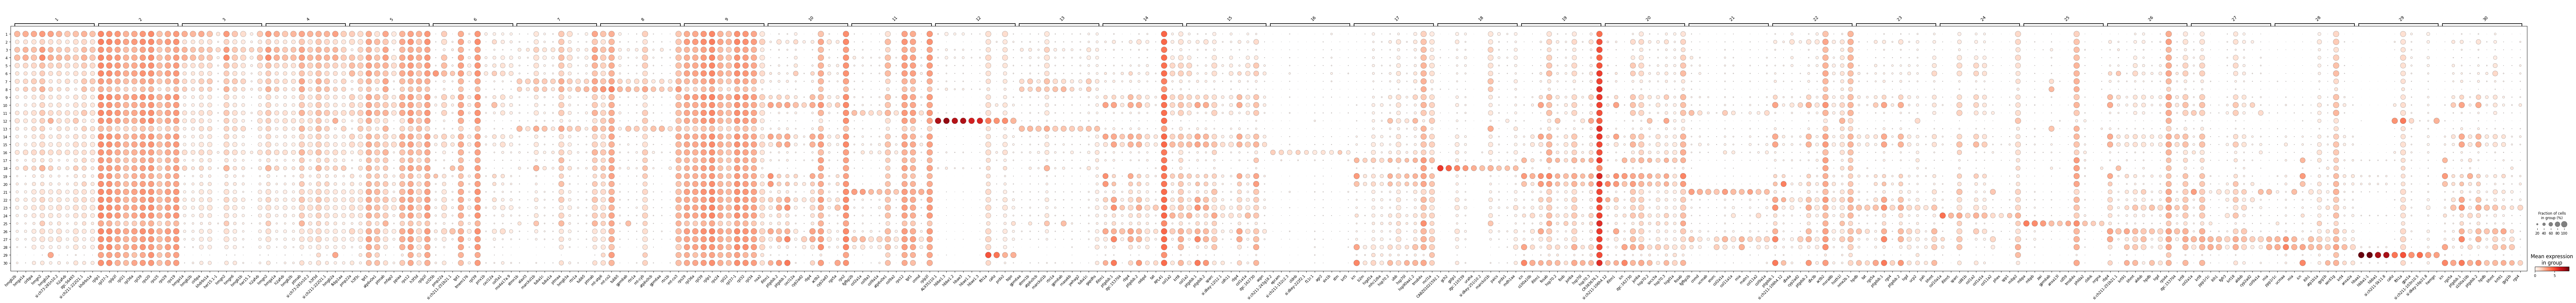

In [14]:
if not rank_genes_column:
    rank_genes_column = f"rank_genes_groups_{clustering_column}"

# Plot dotplot of markers
_ = pl.marker_genes.rank_genes_plot(
    adata,
    key=rank_genes_column,
    n_genes=10,
    style="dots",
    save=f"marker_genes_dots_{clustering_column}.pdf",
    layer=layer,
    report=f"01_marker_genes_dots_{clustering_column}.png"
)

[INFO] Saving figure to ../figures/annotation/compare_annotations.pdf


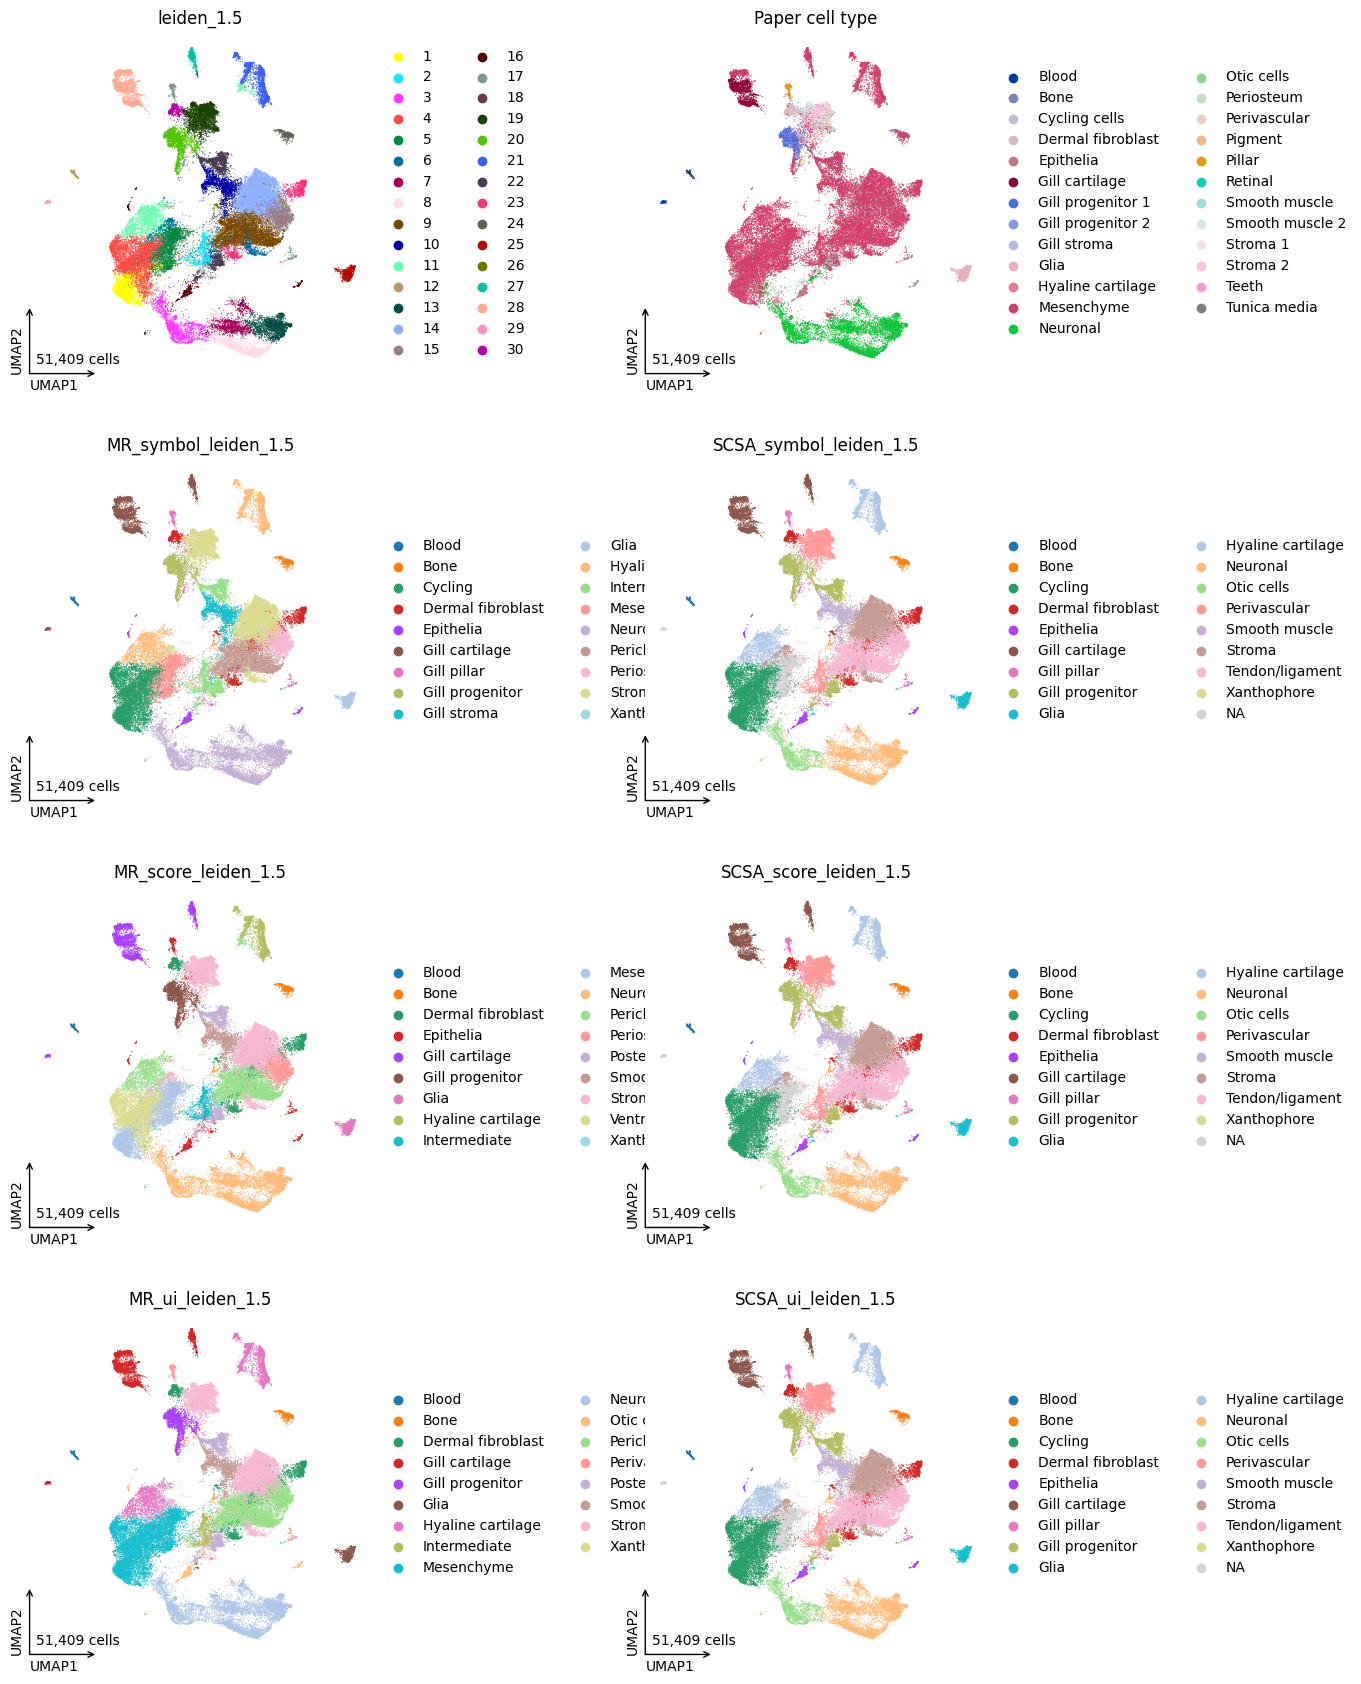

In [15]:
# Plot cell type annotations
columns = [clustering_column] + list(compare_df.columns)
_ = pl.embedding.plot_embedding(adata, method="umap", color=columns, ncols=2,
                                save="compare_annotations.pdf", report="02_compare_annotations.png")

--------------

### 6.1 - Show annotated .obs table

In [16]:
display(adata.obs)

,paper_cluster,filename,sample,timepoint,batch,Paper cell type,Spatial expression domain,total_counts,log1p_total_counts,total_counts_is_mito,log1p_total_counts_is_mito,pct_counts_is_mito,total_counts_is_ribo,log1p_total_counts_is_ribo,pct_counts_is_ribo,doublet_score,predicted_doublet,predicted_sex,n_genes,log1p_n_genes,S_score,G2M_score,phase,Combined timepoint clustering,1.5 dpf pred. cell type,2 dpf pred. cell type,3 dpf pred. cell type,5 dpf pred. cell type,14 dpf pred. cell type,60 dpf pred. cell type,150 dpf pred. cell type,Combined pred. cell type,leiden,LISI_score_X_pca,LISI_score_X_umap,sample_density,timepoint_density,leiden_0.1,leiden_0.2,leiden_0.3,leiden_0.4,leiden_0.5,leiden_0.6,leiden_0.7,leiden_0.8,leiden_0.9,leiden_1.0,leiden_1.1,leiden_1.2,leiden_1.3,leiden_1.4,leiden_1.5,leiden_1.6,leiden_1.7,leiden_1.8,leiden_1.9,clustering,MR_symbol_leiden_1.5,SCSA_symbol_leiden_1.5,MR_score_leiden_1.5,SCSA_score_leiden_1.5,MR_ui_leiden_1.5,SCSA_ui_leiden_1.5
AAACCTGGTTCACCTC-1-1.5dpf,2,GSM5402428_scRNAseq_Sox10_Cre_bact_BtR_1.5dpf_...,GSM5402428,1.5dpf,rep_1,Mesenchyme,Dorsal,6103.0,8.716700,72.0,4.290460,1.179748,2230.0,7.710205,36.539406,0.056507,False,Male,1755,7.470794,0.967606,0.935372,S,1_1.5dpf,Periosteum,NaN,NaN,NaN,NaN,NaN,NaN,Periosteum,0,2.106292,1.805305,0.363366,0.363366,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,Cycling,Cycling,Mesenchyme,Cycling,Mesenchyme,Cycling
AAACCTGTCCCAAGAT-1-1.5dpf,4,GSM5402428_scRNAseq_Sox10_Cre_bact_BtR_1.5dpf_...,GSM5402428,1.5dpf,rep_1,Neuronal,NaN,2433.0,7.797291,20.0,3.044523,0.822030,821.0,6.711740,33.744347,0.017997,False,Male,779,6.659294,-0.260912,-0.043198,G1,2_1.5dpf,Hyaline cartilage,NaN,NaN,NaN,NaN,NaN,NaN,Hyaline cartilage,1,2.356823,3.274661,0.217232,0.217232,3,4,2,2,2,3,7,5,3,2,3,3,2,2,3,3,3,3,2,3,Neuronal,Otic cells,Neuronal,Otic cells,Neuronal,Otic cells
AAACCTGTCTCTAAGG-1-1.5dpf,13,GSM5402428_scRNAseq_Sox10_Cre_bact_BtR_1.5dpf_...,GSM5402428,1.5dpf,rep_1,Otic cells,NaN,4500.0,8.412055,61.0,4.127134,1.355556,1730.0,7.456455,38.444443,0.068627,False,Male,1360,7.215975,0.971314,0.246207,S,3_1.5dpf,Neuronal,NaN,NaN,NaN,NaN,NaN,NaN,Neuronal,2,2.095341,1.243817,0.575938,0.575938,1,1,1,1,1,1,1,1,1,3,1,2,6,3,4,5,3,2,4,4,Cycling,Cycling,Ventral,Cycling,Mesenchyme,Cycling
AAACGGGAGGCTATCT-1-1.5dpf,13,GSM5402428_scRNAseq_Sox10_Cre_bact_BtR_1.5dpf_...,GSM5402428,1.5dpf,rep_1,Otic cells,NaN,4260.0,8.357259,56.0,4.043051,1.314554,1670.0,7.421177,39.201878,0.041345,False,Male,1264,7.142827,-0.084020,-0.124620,G1,3_1.5dpf,Neuronal,NaN,NaN,NaN,NaN,NaN,NaN,Neuronal,7,3.458951,2.069661,0.054441,0.054441,3,4,2,8,3,4,6,6,5,8,5,5,8,10,7,6,10,7,17,7,Neuronal,Neuronal,Neuronal,Neuronal,Neuronal,Neuronal
AAACGGGAGTTACGGG-1-1.5dpf,12,GSM5402428_scRNAseq_Sox10_Cre_bact_BtR_1.5dpf_...,GSM5402428,1.5dpf,rep_1,Glia,NaN,2601.0,7.864036,25.0,3.258096,0.961169,918.0,6.823286,35.294117,0.026172,False,Male,981,6.889591,0.612325,-0.144545,S,4_1.5dpf,Glia,NaN,NaN,NaN,NaN,NaN,NaN,Glia,1,2.792741,2.859354,0.126824,0.126824,1,1,1,1,2,3,7,5,3,2,3,3,2,2,3,10,3,12,2,3,Neuronal,Otic cells,Neuronal,Otic cells,Neuronal,Otic cells
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCACAATAACGA-3-150dpf,4,GSM5402443_scRNAseq_Sox10_Cre_bact_BtR_150dpf_...,GSM5402443,150dpf,rep_3,Gill cartilage,NaN,6016.0,8.702344,66.0,4.204693,1.097074,2881.0,7.966240,47.888962,0.087479,False,Male,1116,7.018402,-0.170935,-0.095224,G1,9_150dpf,NaN,NaN,NaN,NaN,NaN,NaN,Gill cartilage,Gill cartilage,21,1.337022,1.012106,0.976837,0.947656,9,10,13,13,15,17,18,19,21,22,24,26,26,28,28,29,29,32,33,28,Gill cartilage,Gill cartilage,Gill cartilage,Gill cartilage,Gill cartilage,Gill cartilage
TTTGTCAGTCTCCACT-3-150dpf,8,GSM5402443_scRNAseq_Sox10_Cre_bact_BtR_150dpf_...,GSM5402443,150dpf,rep_3,Periosteum,NaN,2241.0,7.715124,38.0,3.663562,

--------------

## 7 - Save adata

In [17]:
utils.io.update_yaml({"annotation": True}, "method.yml", path_prefix="report")
utils.adata.save_h5ad(adata, "anndata_annotated.h5ad")

[INFO] The adata object was saved to: ../adatas/anndata_annotated.h5ad
